# Import libraries

In [2]:
import pandas as pd
!pip install pandas pyarrow

# Import data

In [3]:
taxi_data = pd.read_parquet(r"C:\Users\HP\Desktop\new-york-taxi-analysis\data\yellow_tripdata_2019-01.parquet")
taxi_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,7.0,0.5,0.5,1.65,0.0,0.3,9.95,NaN,None
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,14.0,0.5,0.5,1.00,0.0,0.3,16.30,NaN,None
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,4.5,0.5,0.5,0.00,0.0,0.3,5.80,NaN,None
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,7.55,NaN,None
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.0,0.3,55.55,NaN,None


In [4]:
taxi_data.shape

(7696617, 19)

# Data exploration

In [5]:
taxi_data.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')

In [6]:
taxi_data = taxi_data[['tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID','PULocationID',
       'DOLocationID', 'payment_type',  'total_amount']]

array([[<Axes: title={'center': 'tpep_pickup_datetime'}>,
        <Axes: title={'center': 'tpep_dropoff_datetime'}>,
        <Axes: title={'center': 'passenger_count'}>],
       [<Axes: title={'center': 'trip_distance'}>,
        <Axes: title={'center': 'RatecodeID'}>,
        <Axes: title={'center': 'PULocationID'}>],
       [<Axes: title={'center': 'DOLocationID'}>,
        <Axes: title={'center': 'payment_type'}>,
        <Axes: title={'center': 'total_amount'}>]], dtype=object)

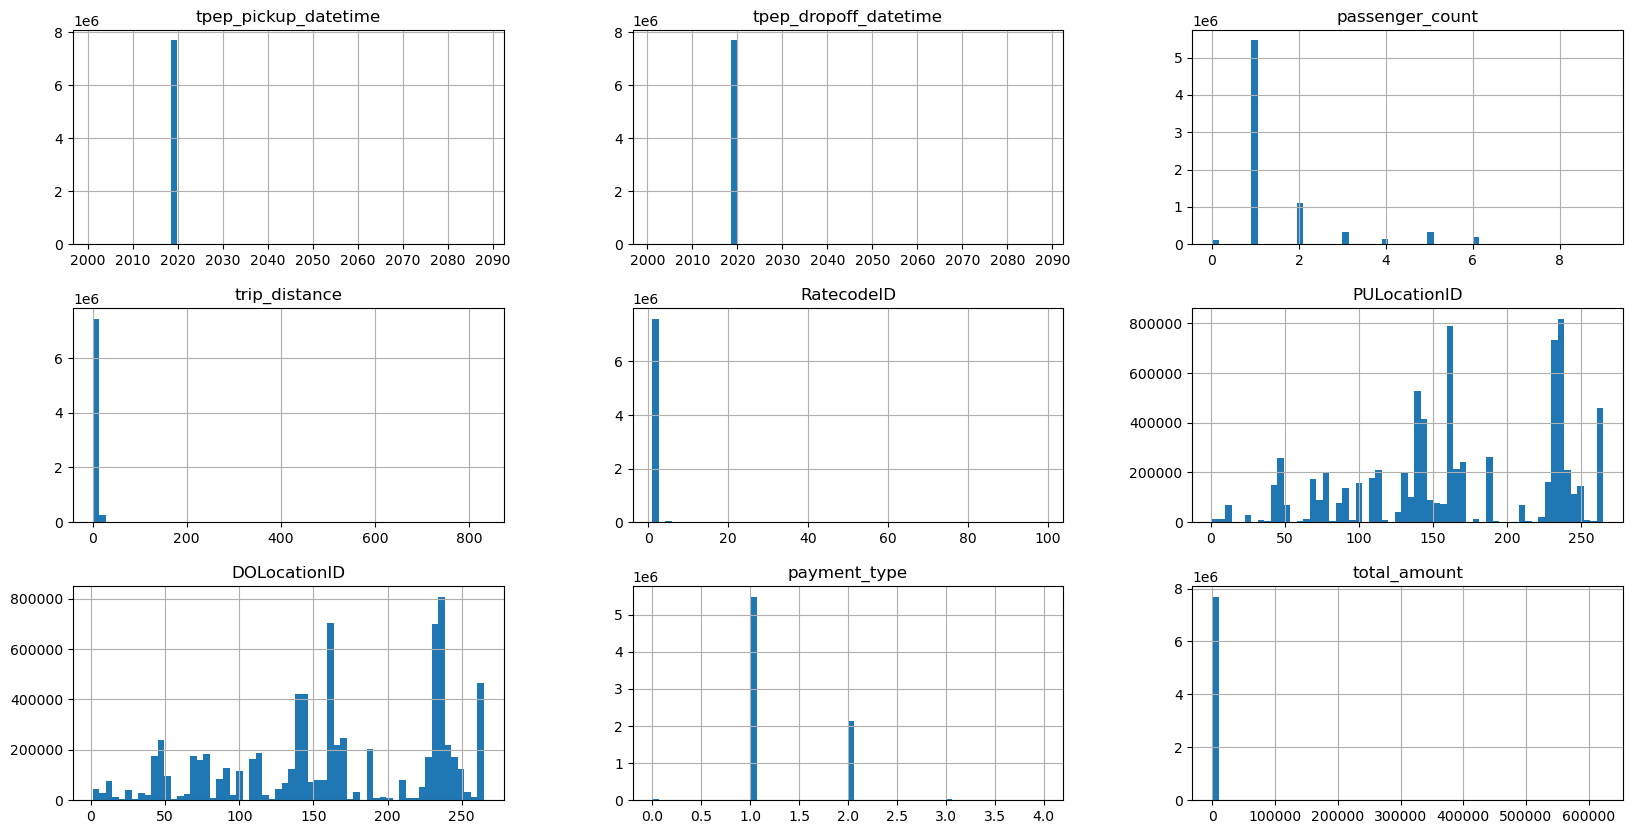

In [7]:
taxi_data.hist(figsize=(20,10), bins=60)

In [8]:
taxi_data['RatecodeID'].value_counts()

RatecodeID
1.0     7430288
2.0      166093
5.0       54570
3.0       11801
4.0        4895
99.0        252
6.0          46
Name: count, dtype: int64

<Axes: xlabel='index', ylabel='total_amount'>

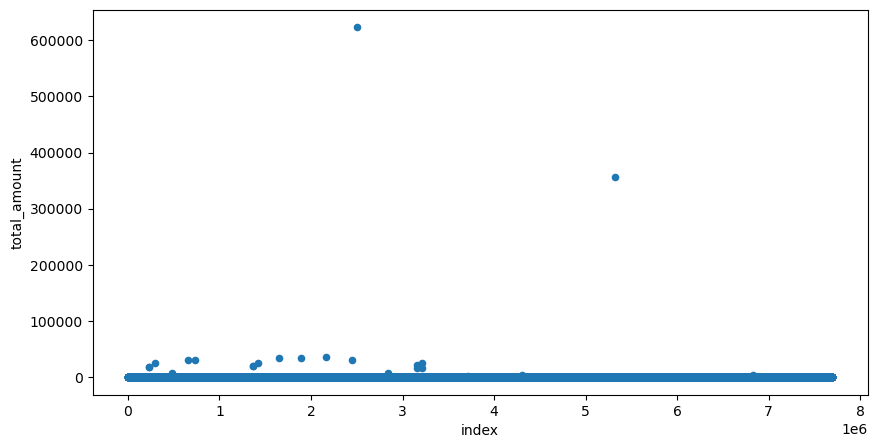

In [9]:
taxi_data.reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10,5))

<Axes: xlabel='index', ylabel='total_amount'>

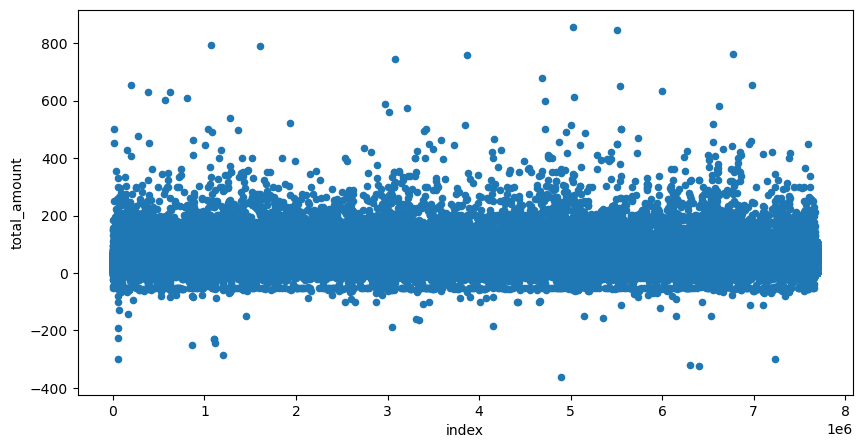

In [10]:
taxi_data[taxi_data['total_amount']<1000].reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10,5))

### Two things to deal with: negative values and very high values. Let's first look at negative values.

(7127, 9)


<Axes: xlabel='index', ylabel='total_amount'>

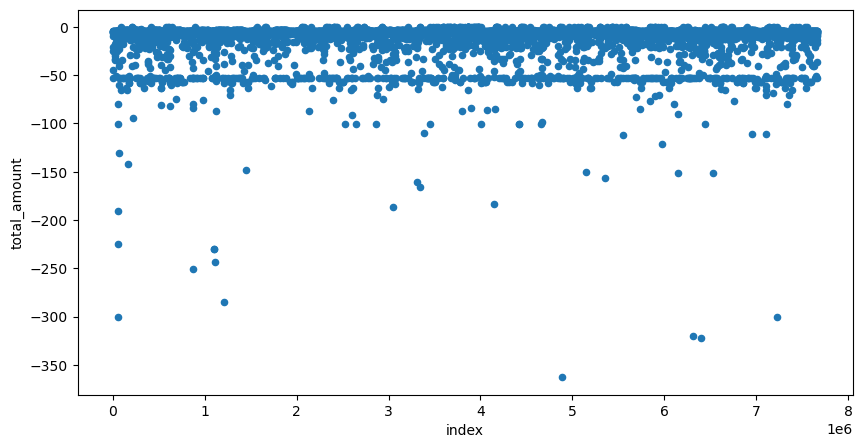

In [11]:
print(taxi_data[taxi_data['total_amount']<0].shape)
taxi_data[taxi_data['total_amount']<0].reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10,5))

In [12]:
taxi_data[taxi_data['total_amount']<0].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
663,2019-01-01 00:32:56,2019-01-01 00:33:35,2.0,0.10,1.0,148,148,3,-3.8
2402,2019-01-01 00:14:18,2019-01-01 00:40:55,1.0,4.13,1.0,170,238,4,-20.3
2541,2019-01-01 00:31:27,2019-01-01 00:42:39,1.0,1.35,1.0,162,234,4,-9.8
2544,2019-01-01 00:45:57,2019-01-01 00:46:07,1.0,0.00,1.0,234,234,4,-3.8
2547,2019-01-01 00:48:35,2019-01-01 00:49:59,1.0,0.16,1.0,234,234,4,-4.3


In [13]:
taxi_data[taxi_data['total_amount']<0]['payment_type'].value_counts()

payment_type
3    4083
4    2667
2     376
1       1
Name: count, dtype: int64

<Axes: >

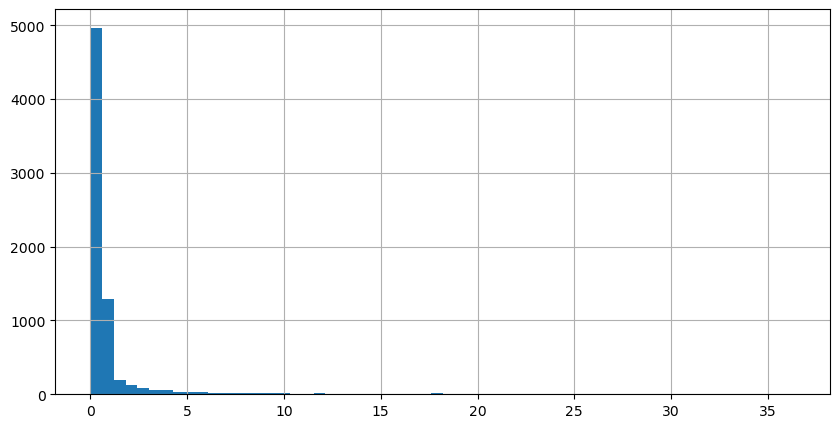

In [14]:
taxi_data[taxi_data['total_amount']<0]['trip_distance'].hist(bins=60, figsize=(10,5))

In [15]:
print(taxi_data[taxi_data['total_amount']==0].shape)
taxi_data[taxi_data['total_amount']==0].head()

(1643, 9)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
3552,2019-01-01 00:18:46,2019-01-01 00:18:46,1.0,0.0,5.0,186,264,2,0.0
9138,2019-01-01 00:41:47,2019-01-01 00:41:47,1.0,0.0,5.0,246,264,2,0.0
13256,2019-01-01 00:19:38,2019-01-01 00:20:35,1.0,0.0,1.0,193,193,1,0.0
13257,2019-01-01 00:43:34,2019-01-01 00:43:34,1.0,0.0,1.0,7,7,2,0.0
13258,2019-01-01 00:02:52,2019-01-01 00:02:52,1.0,0.0,1.0,264,7,2,0.0


In [16]:
taxi_data[taxi_data['total_amount']==0]['payment_type'].value_counts()

payment_type
1    813
2    569
0    231
3     29
4      1
Name: count, dtype: int64

<Axes: >

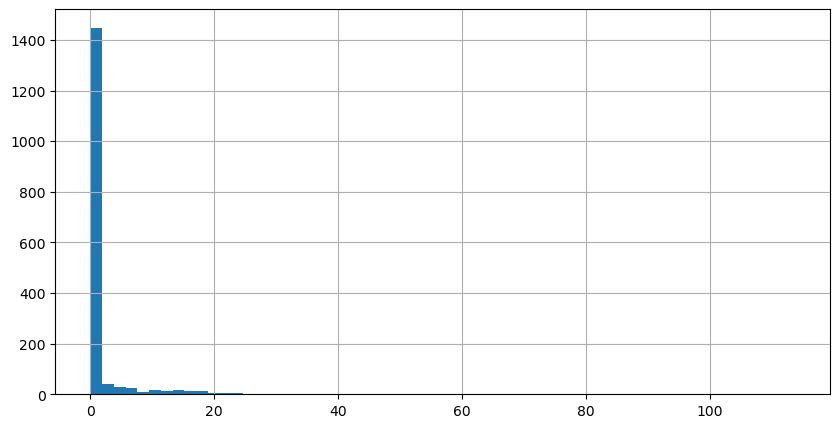

In [17]:
taxi_data[taxi_data['total_amount']==0]['trip_distance'].hist(bins=60, figsize=(10,5))

In [18]:
taxi_data[taxi_data['total_amount']==0]['trip_distance'].value_counts()

trip_distance
0.00     1323
0.03        9
0.01        8
0.06        6
1.00        4
         ... 
11.86       1
4.59        1
20.92       1
18.37       1
12.30       1
Name: count, Length: 256, dtype: int64

### We can safely get rid of the negative values. What about the very high values?

<Axes: xlabel='index', ylabel='total_amount'>

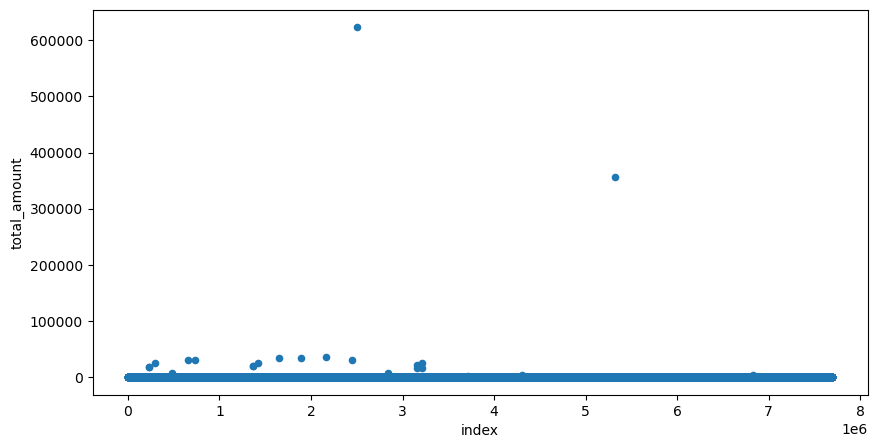

In [19]:
taxi_data.reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10,5))

In [23]:
taxi_data[taxi_data['total_amount']>200].shape


(1166, 9)

In [24]:
taxi_data['total_amount'].mean()

np.float64(15.810651344610237)

### We can agree to cut from $200 level.

In [26]:
taxi_data_filtered = taxi_data[(taxi_data['total_amount']>=0)&(taxi_data['total_amount']<200)]

In [27]:
print(taxi_data.shape)
taxi_data_filtered.shape

(7696617, 9)


(7688319, 9)

### Any missing values?

<Axes: xlabel='index', ylabel='total_amount'>

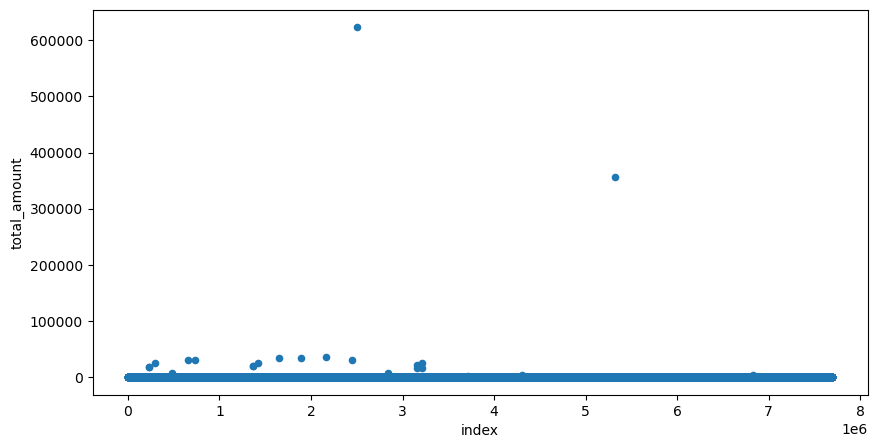

In [29]:
taxi_data.reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10,5))

In [30]:
taxi_data[taxi_data['passenger_count']<=0]['RatecodeID'].value_counts()
taxi_data_filtered[
    (taxi_data_filtered['passenger_count'] == 0)
]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
156,2019-01-01 00:32:24,2019-01-01 00:33:21,0.0,5.3,1.0,50,50,1,4.55
228,2019-01-01 00:00:50,2019-01-01 00:31:48,0.0,18.0,2.0,132,140,1,59.80
229,2019-01-01 00:38:32,2019-01-01 01:09:51,0.0,8.9,1.0,229,37,1,38.50
298,2019-01-01 00:45:19,2019-01-01 00:55:53,0.0,1.0,1.0,107,170,2,9.30
905,2019-01-01 00:20:15,2019-01-01 00:26:42,0.0,0.7,1.0,90,249,1,8.30
...,...,...,...,...,...,...,...,...,...
7667705,2019-01-31 23:56:07,2019-02-01 00:13:46,0.0,2.8,1.0,264,264,1,16.30
7667734,2019-01-31 23:36:42,2019-01-31 23:57:43,0.0,4.8,1.0,161,13,1,20.80
7667765,2019-01-31 23:06:23,2019-01-31 23:18:20,0.0,3.2,1.0,68,239,1,15.95
7667917,2019-01-31 23:06:51,2019-01-31 23:15:06,0.0,1.4,1.0,162,186,2,8.80


In [31]:
taxi_data_filtered['passenger_count'].value_counts()
taxi_data_filtered = taxi_data_filtered[
    ~taxi_data_filtered['passenger_count'].isin([6, 7, 8, 9])
]
taxi_data_filtered['passenger_count'].value_counts()

passenger_count
1.0    5450602
2.0    1112657
5.0     323448
3.0     314333
4.0     140626
0.0     117310
Name: count, dtype: int64

In [32]:
taxi_data_filtered.isna().sum()

tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          28672
trip_distance                0
RatecodeID               28672
PULocationID                 0
DOLocationID                 0
payment_type                 0
total_amount                 0
dtype: int64

In [33]:
taxi_data_filtered[taxi_data_filtered['passenger_count'].isna()]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
7667945,2019-01-01 00:38:45,2019-01-01 00:54:11,NaN,2.21,NaN,161,263,0,16.30
7667946,2019-01-01 01:56:58,2019-01-01 02:13:14,NaN,3.17,NaN,256,226,0,19.59
7667947,2019-01-01 01:59:06,2019-01-01 02:20:24,NaN,6.31,NaN,140,256,0,34.04
7667948,2019-01-01 02:34:00,2019-01-01 02:34:00,NaN,0.00,NaN,233,233,0,0.00
7667949,2019-01-01 02:44:00,2019-01-01 03:03:00,NaN,11.86,NaN,246,265,0,0.00
...,...,...,...,...,...,...,...,...,...
7696612,2019-01-31 23:37:20,2019-02-01 00:10:43,NaN,10.24,NaN,142,95,0,0.00
7696613,2019-01-31 23:28:00,2019-01-31 23:50:50,NaN,12.43,NaN,48,213,0,54.60
7696614,2019-01-31 23:11:00,2019-01-31 23:46:00,NaN,9.14,NaN,159,246,0,54.60
7696615,2019-01-31 23:03:00,2019-01-31 23:14:00,NaN,0.00,NaN,265,265,0,0.00


In [35]:
taxi_data_filtered = taxi_data.copy()

In [36]:
total_rows = len(taxi_data_filtered)

invalid_rows = (
    taxi_data_filtered['passenger_count'].isna() &
    taxi_data_filtered['RatecodeID'].isna()
).sum()

print("Total rows:", total_rows)
print("Invalid rows:", invalid_rows)
print("Percentage:", invalid_rows / total_rows * 100)


Total rows: 7696617
Invalid rows: 28672
Percentage: 0.37252730647763815


In [37]:
taxi_data_filtered = taxi_data_filtered.dropna(
    subset=['passenger_count', 'RatecodeID'],
    how='all'
)

In [38]:
taxi_data_filtered.isna().sum()

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
total_amount             0
dtype: int64

# Data Preparation

In [39]:
taxi_data_prepared = taxi_data_filtered.copy()

In [40]:
lower_limit = taxi_data_prepared['total_amount'].quantile(0.01)
upper_limit = taxi_data_prepared['total_amount'].quantile(0.99)

taxi_data_prepared = taxi_data_prepared[
    (taxi_data_prepared['total_amount'] >= lower_limit) &
    (taxi_data_prepared['total_amount'] <= upper_limit)
]

In [41]:
taxi_data_prepared.dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
total_amount                    float64
dtype: object

In [42]:
taxi_data_prepared.loc[:,'tpep_pickup_datetime'] = pd.to_datetime(taxi_data_prepared.loc[:,'tpep_pickup_datetime'])
taxi_data_prepared.loc[:,'tpep_dropoff_datetime'] = pd.to_datetime(taxi_data_prepared.loc[:,'tpep_dropoff_datetime'])

In [44]:
taxi_data_prepared['transaction_date'] = pd.to_datetime(taxi_data_prepared['tpep_pickup_datetime'].dt.date)
taxi_data_prepared['transaction_year'] = taxi_data_prepared['tpep_pickup_datetime'].dt.year
taxi_data_prepared['transaction_month'] = taxi_data_prepared['tpep_pickup_datetime'].dt.month
taxi_data_prepared['transaction_day'] =  taxi_data_prepared['tpep_pickup_datetime'].dt.day
taxi_data_prepared['transaction_hour'] = taxi_data_prepared['tpep_pickup_datetime'].dt.hour

In [45]:
taxi_data_prepared.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount,transaction_date,transaction_year,transaction_month,transaction_day,transaction_hour
0,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,151,239,1,9.95,2019-01-01,2019,1,1,0
1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,239,246,1,16.30,2019-01-01,2019,1,1,0
2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,236,236,1,5.80,2018-12-21,2018,12,21,13
3,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,193,193,2,7.55,2018-11-28,2018,11,28,15
4,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,193,193,2,55.55,2018-11-28,2018,11,28,15


### We are working only on Jan 2019 data, we will be removing others.

In [46]:
taxi_data_prepared = taxi_data_prepared[taxi_data_prepared['transaction_year']==2019]
taxi_data_prepared = taxi_data_prepared[taxi_data_prepared['transaction_month']==1]
categorical_columns = ['PULocationID','transaction_date','transaction_month','transaction_day','transaction_hour']
numerical_columns = ['trip_distance','total_amount']
all_needed_columns = categorical_columns + numerical_columns

In [47]:
main_taxi_df = taxi_data_prepared[all_needed_columns]
print(main_taxi_df.shape)
main_taxi_df.head()


(7550357, 7)


,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount
0,151,2019-01-01,1,1,0,1.5,9.95
1,239,2019-01-01,1,1,0,2.6,16.30
7,163,2019-01-01,1,1,0,1.3,9.05
8,229,2019-01-01,1,1,0,3.7,18.50
9,141,2019-01-01,1,1,0,2.1,13.00


### Aggregate data points. Now is a good time to think about what we want to predict. Depending on this, we need to transform our data to have a certain format.

In [48]:
taxi_grouped_by_region = main_taxi_df.groupby(categorical_columns).mean().reset_index()
taxi_grouped_by_region['count_of_transactions'] = main_taxi_df.groupby(categorical_columns).count().reset_index()['total_amount']
print(taxi_grouped_by_region.shape)
taxi_grouped_by_region.head()

(100004, 8)


,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions
0,1,2019-01-01,1,1,2,0.00,21.80,1
1,1,2019-01-01,1,1,10,16.90,16.56,2
2,1,2019-01-01,1,1,15,0.00,40.30,1
3,1,2019-01-02,1,2,2,1.27,30.30,1
4,1,2019-01-02,1,2,3,12.65,15.30,1


<Axes: >

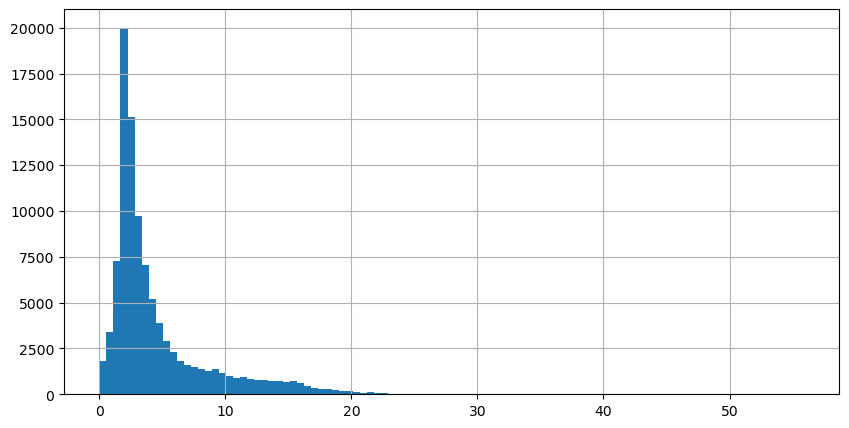

In [49]:
taxi_grouped_by_region['trip_distance'].hist(bins=100, figsize=(10,5))

<Axes: >

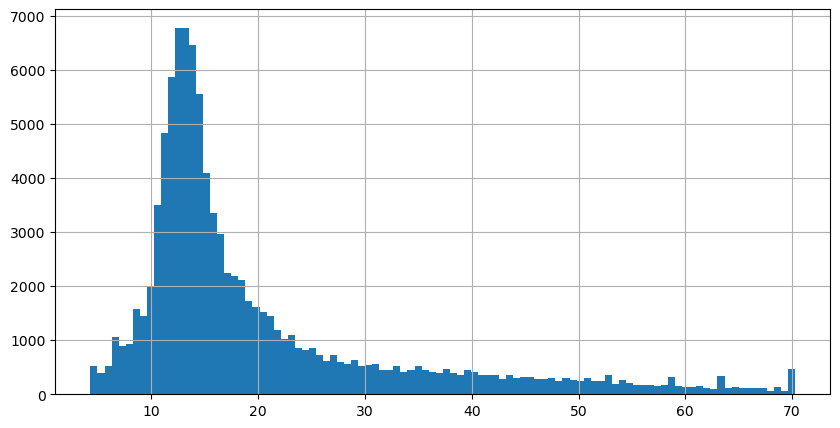

In [51]:
taxi_grouped_by_region['total_amount'].hist(bins=100, figsize=(10,5))


# Benchmark Model

In [54]:
data_for_benchmark_model = taxi_grouped_by_region.copy()

In [75]:
categorical_features_benchmark = ['PULocationID','transaction_month','transaction_day','transaction_hour']
input_features_benchmark  = categorical_features_benchmark
target_feature_benchmark  = 'total_amount'

In [89]:
data_for_benchmark_model
sample_df = data_for_benchmark_model.sample(100000, random_state=42)
sample_df.dropna(subset=[target_feature_benchmark], inplace=True)

In [90]:
X = sample_df[input_features_benchmark]
y = sample_df[target_feature_benchmark]
X = pd.get_dummies(X)
X = X.fillna(0)


### Train-test split

In [91]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42)

### Fit a model to the data

In [92]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=30,
    max_depth=12,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,30
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [93]:
y_pred_rf = rf.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt

mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print('Mean Absolute Error (MAE):', mae)
print('Mean Squared Error (MSE):', mse)
print('Root Mean Squared Error (RMSE):', rmse)
print('R² Score:', r2)

Mean Absolute Error (MAE): 6.39140881558681
Mean Squared Error (MSE): 102.50284505720376
Root Mean Squared Error (RMSE): 10.124368872043519
R² Score: 0.4223757764500302


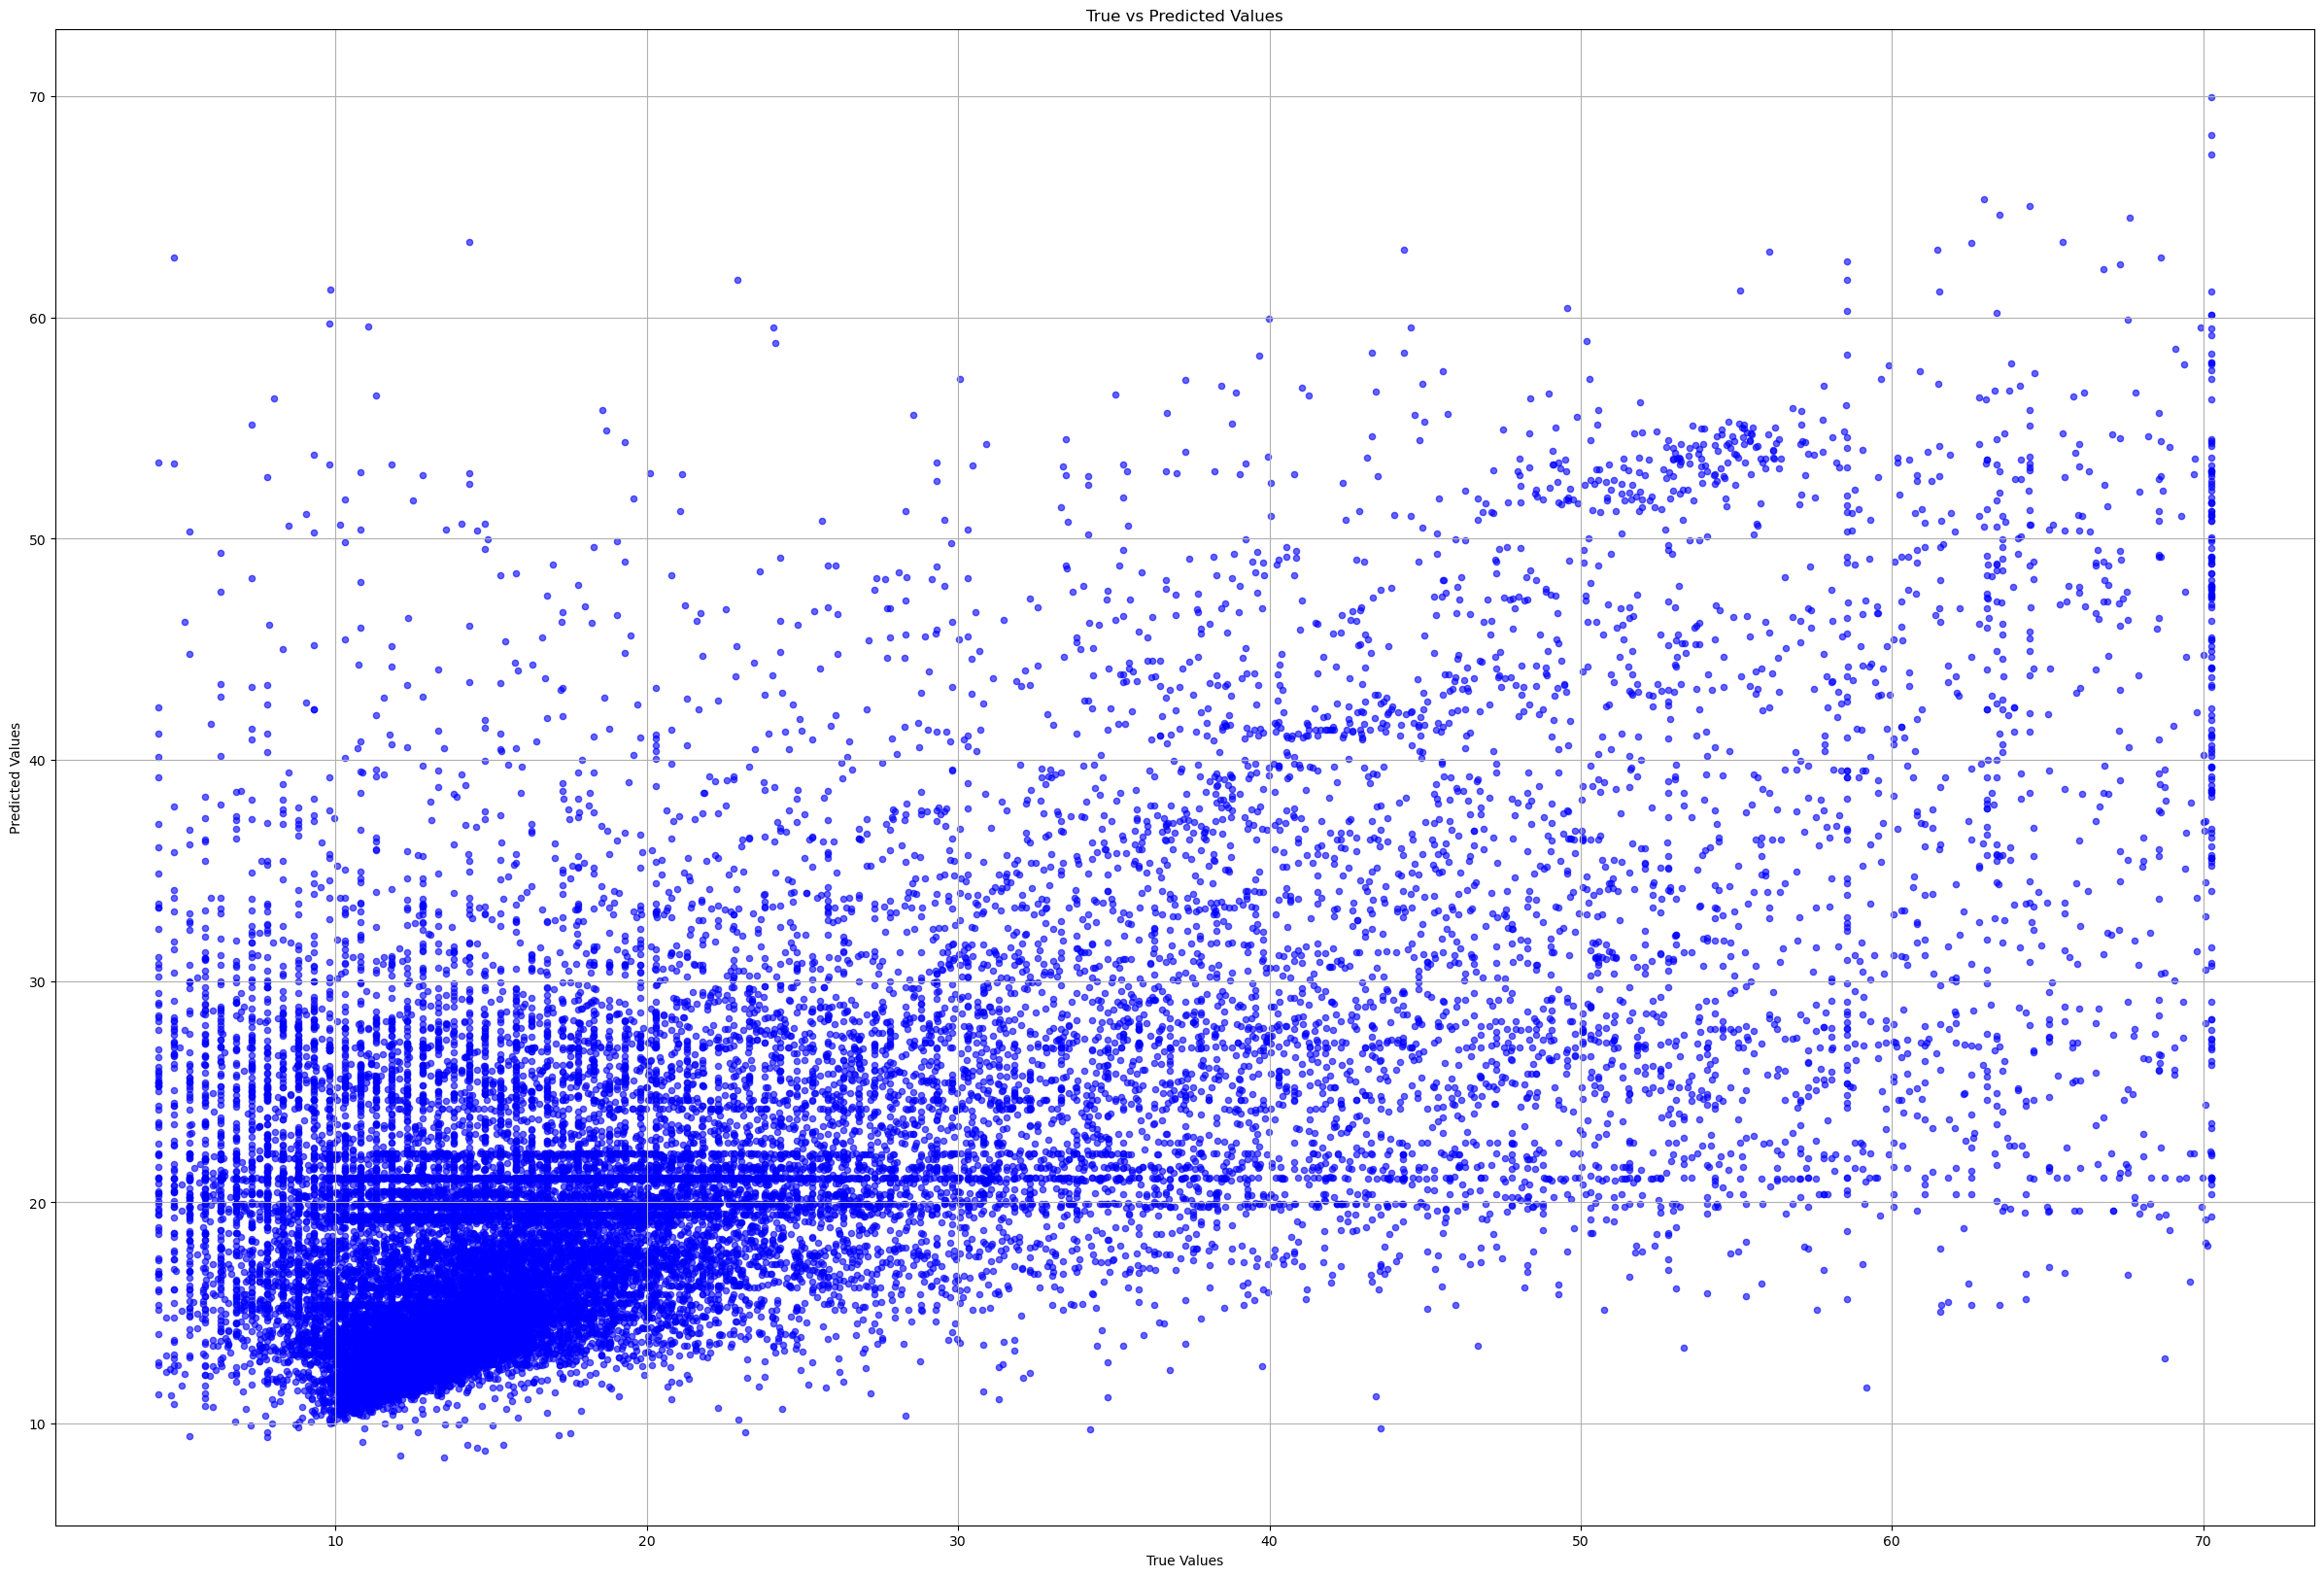

In [95]:
import matplotlib.pyplot as plt

data = {'True Values': y_test, 'Predicted Values': y_pred_rf}
results = pd.DataFrame(data)

results.plot(
    figsize=(30, 20),
    kind='scatter',
    x='True Values',
    y='Predicted Values',
    color='blue',
    alpha=0.6
)

plt.title('True vs Predicted Values')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()

# Feature Engineering

In [96]:
data_with_new_features = taxi_grouped_by_region.copy()

In [97]:
data_with_new_features['transaction_week_day'] = data_with_new_features['transaction_date'].dt.weekday
data_with_new_features['weekend'] = data_with_new_features['transaction_week_day'].apply(lambda x: True if x == 5 or x == 6 else False)

In [100]:
data_with_new_features['transaction_date'] = pd.to_datetime(data_with_new_features['transaction_date'])
data_with_new_features['is_holiday'] = data_with_new_features['transaction_date'].dt.date.isin(holidays)

In [101]:
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday
0,1,2019-01-01,1,1,2,0.00,21.80,1,1,False,True
1,1,2019-01-01,1,1,10,16.90,16.56,2,1,False,True
2,1,2019-01-01,1,1,15,0.00,40.30,1,1,False,True
3,1,2019-01-02,1,2,2,1.27,30.30,1,2,False,False
4,1,2019-01-02,1,2,3,12.65,15.30,1,2,False,False


In [107]:
import pandas as pd

zone_lookup = pd.read_csv(r'C:\Users\HP\Desktop\taxi_zone_lookup.csv')
zone_lookup = zone_lookup[['LocationID','Borough']]
zone_lookup['LocationID'] = zone_lookup['LocationID'].astype(str)
zone_lookup.head()

,LocationID,Borough
0,1,EWR
1,2,Queens
2,3,Bronx
3,4,Manhattan
4,5,Staten Island


In [109]:
zone_lookup['LocationID'] = zone_lookup['LocationID'].astype('int64')
data_with_new_features = data_with_new_features.merge(zone_lookup, left_on='PULocationID', right_on='LocationID', how='left')
data_with_new_features.drop('LocationID', axis=1, inplace=True)
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough
0,1,2019-01-01,1,1,2,0.00,21.80,1,1,False,True,EWR
1,1,2019-01-01,1,1,10,16.90,16.56,2,1,False,True,EWR
2,1,2019-01-01,1,1,15,0.00,40.30,1,1,False,True,EWR
3,1,2019-01-02,1,2,2,1.27,30.30,1,2,False,False,EWR
4,1,2019-01-02,1,2,3,12.65,15.30,1,2,False,False,EWR


In [110]:
data_with_new_features['Borough'].value_counts()

Borough
Manhattan        45225
Brooklyn         22993
Queens           20996
Bronx             9172
Unknown            744
Staten Island      197
EWR                 54
Name: count, dtype: int64

In [129]:
nyc_weather = pd.read_csv(r"C:\Users\HP\Desktop\nyc_temperature.csv")
nyc_weather.head()

,date,tmax,tmin,tavg,departure,HDD,CDD,precipitation,new_snow,snow_depth
0,1/1/19,60,40,50.0,13.9,15,0,0.08,0,0
1,2/1/19,41,35,38.0,2.1,27,0,0,0,0
2,3/1/19,45,39,42.0,6.3,23,0,T,0,0
3,4/1/19,47,37,42.0,6.5,23,0,0,0,0
4,5/1/19,47,42,44.5,9.1,20,0,0.45,0,0


In [130]:
nyc_weather.columns

Index(['date', 'tmax', 'tmin', 'tavg', 'departure', 'HDD', 'CDD',
       'precipitation', 'new_snow', 'snow_depth'],
      dtype='object')

In [131]:
nyc_weather.shape

(365, 10)

In [132]:

nyc_weather_nonzero_cdd = nyc_weather[nyc_weather['CDD'] != 0]
nyc_weather_nonzero_cdd

,date,tmax,tmin,tavg,departure,HDD,CDD,precipitation,new_snow,snow_depth
102,13/4/19,75,58,66.5,13.7,0,2,0.28,0,0
108,19/4/19,76,55,65.5,10.4,0,1,0.1,0,0
136,17/5/19,78,63,70.5,6.5,0,6,0.03,0,0
137,18/5/19,75,59,67.0,2.7,0,2,0,0,0
138,19/5/19,76,60,68.0,3.4,0,3,0.03,0,0
...,...,...,...,...,...,...,...,...,...,...
272,30/9/19,72,61,66.5,0.8,0,2,T,0,0
273,1/10/19,82,64,73.0,7.7,0,8,0,0,0
274,2/10/19,95,63,79.0,14.1,0,14,0.21,0,0
279,7/10/19,79,60,69.5,6.5,0,5,0.03,0,0


In [135]:
nyc_weather['new_snow'].unique()

array(['0', 'T', '0.4', '0.2', '1.5', '1.4', '0.1', '1.2', '3.8', '2.5',
       '2.3', '0.3', '0.9', '0.5'], dtype=object)

In [137]:

nyc_weather['new_snow'] = pd.to_numeric(nyc_weather['new_snow'], errors='coerce')
nyc_weather['new_snow'] = nyc_weather['new_snow'].fillna(0)
nyc_weather['new_snow'] = nyc_weather['new_snow'].apply(lambda x: 0 if x < 0.01 else x)
no_snow_days = nyc_weather[nyc_weather['new_snow'] == 0]
no_snow_days

,date,tmax,tmin,tavg,departure,HDD,CDD,precipitation,new_snow,snow_depth
0,1/1/19,60,40,50.0,13.9,15,0,0.08,0.0,0
1,2/1/19,41,35,38.0,2.1,27,0,0,0.0,0
2,3/1/19,45,39,42.0,6.3,23,0,T,0.0,0
3,4/1/19,47,37,42.0,6.5,23,0,0,0.0,0
4,5/1/19,47,42,44.5,9.1,20,0,0.45,0.0,0
...,...,...,...,...,...,...,...,...,...,...
360,27/12/19,54,42,48.0,10.8,17,0,T,0.0,0
361,28/12/19,50,44,47.0,10.0,18,0,0,0.0,0
362,29/12/19,44,38,41.0,4.3,24,0,0.29,0.0,0
363,30/12/19,43,38,40.5,4.0,24,0,0.49,0.0,0


In [138]:
nyc_weather.drop(columns=['CDD', 'HDD','tmax','tmin','departure'], inplace=True)

In [139]:
nyc_weather.head()

,date,tavg,precipitation,new_snow,snow_depth
0,1/1/19,50.0,0.08,0.0,0
1,2/1/19,38.0,0,0.0,0
2,3/1/19,42.0,T,0.0,0
3,4/1/19,42.0,0,0.0,0
4,5/1/19,44.5,0.45,0.0,0


In [140]:
nyc_weather['precipitation'].unique()

array(['0.08', '0', 'T', '0.45', '0.21', '0.07', '0.03', '0.34', '1',
       '1.48', '0.27', '0.47', '0.11', '0.37', '0.7', '0.06', '0.04',
       '0.1', '0.59', '0.14', '0.73', '0.51', '0.35', '0.66', '0.69',
       '0.53', '0.23', '0.25', '0.02', '0.48', '0.28', '0.78', '0.01',
       '0.58', '0.29', '1.1', '0.05', '0.13', '1.33', '1.22', '0.2',
       '0.09', '0.19', '0.83', '0.8', '0.39', '0.65', '0.63', '0.91',
       '0.54', '0.42', '0.72', '2.67', '0.32', '1.24', '0.52', '0.12',
       '0.62', '1.18', '1.71', '0.46', '1.41', '0.43', '0.56', '0.4',
       '1.8', '0.17', '1.01', '1.13', '0.9', '0.49'], dtype=object)

In [141]:

nyc_weather.dtypes

date              object
tavg             float64
precipitation     object
new_snow         float64
snow_depth        object
dtype: object

In [142]:
nyc_weather['precipitation'].value_counts()

precipitation
0       176
T        52
0.02     10
0.01      9
0.03      9
       ... 
0.19      1
0.83      1
0.8       1
0.65      1
0.49      1
Name: count, Length: 71, dtype: int64

In [143]:
nyc_weather.isna().sum()

date             0
tavg             0
precipitation    0
new_snow         0
snow_depth       0
dtype: int64

In [144]:
nyc_weather['precipitation'] = nyc_weather['precipitation'].replace('T', 0.1)
nyc_weather['precipitation'] = nyc_weather['precipitation'].astype(float)

In [147]:

nyc_weather['date'] = pd.to_datetime(nyc_weather['date'])
nyc_weather['hour'] = nyc_weather['date'].dt.hour
nyc_weather['month'] = nyc_weather['date'].dt.month
nyc_weather['day'] = nyc_weather['date'].dt.day

In [148]:
nyc_weather.head()

,date,tavg,precipitation,new_snow,snow_depth,date and time,hour,month,day
0,2019-01-01,50.0,0.08,0.0,0,2019-01-01,0,1,1
1,2019-02-01,38.0,0.00,0.0,0,2019-02-01,0,2,1
2,2019-03-01,42.0,0.10,0.0,0,2019-03-01,0,3,1
3,2019-04-01,42.0,0.00,0.0,0,2019-04-01,0,4,1
4,2019-05-01,44.5,0.45,0.0,0,2019-05-01,0,5,1


In [149]:
data_with_new_features.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough
0,1,2019-01-01,1,1,2,0.00,21.80,1,1,False,True,EWR
1,1,2019-01-01,1,1,10,16.90,16.56,2,1,False,True,EWR
2,1,2019-01-01,1,1,15,0.00,40.30,1,1,False,True,EWR
3,1,2019-01-02,1,2,2,1.27,30.30,1,2,False,False,EWR
4,1,2019-01-02,1,2,3,12.65,15.30,1,2,False,False,EWR


In [150]:
nyc_taxi_with_weather = data_with_new_features.merge(nyc_weather, left_on = ['transaction_month','transaction_day','transaction_hour'], right_on = ['month','day','hour'], how='left')

print(nyc_taxi_with_weather.shape)
nyc_taxi_with_weather.head()

(100004, 21)


,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,...,Borough,date,tavg,precipitation,new_snow,snow_depth,date and time,hour,month,day
0,1,2019-01-01,1,1,2,0.00,21.80,1,1,False,...,EWR,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,1,2019-01-01,1,1,10,16.90,16.56,2,1,False,...,EWR,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,1,2019-01-01,1,1,15,0.00,40.30,1,1,False,...,EWR,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,1,2019-01-02,1,2,2,1.27,30.30,1,2,False,...,EWR,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
4,1,2019-01-02,1,2,3,12.65,15.30,1,2,False,...,EWR,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN


In [151]:
nyc_taxi_with_weather = nyc_taxi_with_weather.drop(['date and time','hour','month','day'], axis=1)

In [152]:
nyc_taxi_with_weather.head()

,PULocationID,transaction_date,transaction_month,transaction_day,transaction_hour,trip_distance,total_amount,count_of_transactions,transaction_week_day,weekend,is_holiday,Borough,date,tavg,precipitation,new_snow,snow_depth
0,1,2019-01-01,1,1,2,0.00,21.80,1,1,False,True,EWR,NaT,NaN,NaN,NaN,NaN
1,1,2019-01-01,1,1,10,16.90,16.56,2,1,False,True,EWR,NaT,NaN,NaN,NaN,NaN
2,1,2019-01-01,1,1,15,0.00,40.30,1,1,False,True,EWR,NaT,NaN,NaN,NaN,NaN
3,1,2019-01-02,1,2,2,1.27,30.30,1,2,False,False,EWR,NaT,NaN,NaN,NaN,NaN
4,1,2019-01-02,1,2,3,12.65,15.30,1,2,False,False,EWR,NaT,NaN,NaN,NaN,NaN


In [153]:

nyc_taxi_with_weather.isna().sum()

PULocationID                 0
transaction_date             0
transaction_month            0
transaction_day              0
transaction_hour             0
trip_distance                0
total_amount                 0
count_of_transactions        0
transaction_week_day         0
weekend                      0
is_holiday                   0
Borough                    623
date                     96405
tavg                     96405
precipitation            96405
new_snow                 96405
snow_depth               96405
dtype: int64

In [154]:
nyc_taxi_with_weather = nyc_taxi_with_weather.sort_values(['transaction_date','transaction_hour']).reset_index().drop('index',axis=1)

In [160]:
numeric_cols = nyc_taxi_with_weather.select_dtypes(include=np.number).columns
nyc_taxi_with_weather[numeric_cols] = nyc_taxi_with_weather[numeric_cols].interpolate()
nyc_taxi_with_weather[numeric_cols] = nyc_taxi_with_weather[numeric_cols].bfill()

In [161]:
nyc_taxi_with_weather.isna().sum()

PULocationID                0
transaction_date            0
transaction_month           0
transaction_day             0
transaction_hour            0
trip_distance               0
total_amount                0
count_of_transactions       0
transaction_week_day        0
weekend                     0
is_holiday                  0
Borough                     1
date                        0
tavg                        0
precipitation               0
new_snow                    0
snow_depth               3023
dtype: int64

In [162]:
nyc_taxi_with_weather['snow_depth'] = nyc_taxi_with_weather['snow_depth'].fillna(0)
nyc_taxi_with_weather['Bor'] = nyc_taxi_with_weather['snow_depth'].fillna(0)